# 載入波士頓住房價格資料集


In [ ]:
from tensorflow.keras.datasets import boston_housing
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()
# 將標籤分別存成train_targets和test_targets(訓練標籤，測試標籤)
# tensorflow.keras.datasets 用於載入預設資料集，如本例中的波士頓住房價格資料集。

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [ ]:
train_data.shape #查看訓練資料的shape(資料結構[特別是陣列或張量]的維度大小，它描述了資料有多少「行」和多少「列」)

(404, 13)

In [ ]:
test_data.shape #查看測驗資料的shape

(102, 13)

In [ ]:
train_targets #訓練資料的目標值，就是實際成交房價的中位數

array([15.2, 42.3, 50. , 21.1, 17.7, 18.5, 11.3, 15.6, 15.6, 14.4, 12.1,
       17.9, 23.1, 19.9, 15.7,  8.8, 50. , 22.5, 24.1, 27.5, 10.9, 30.8,
       32.9, 24. , 18.5, 13.3, 22.9, 34.7, 16.6, 17.5, 22.3, 16.1, 14.9,
       23.1, 34.9, 25. , 13.9, 13.1, 20.4, 20. , 15.2, 24.7, 22.2, 16.7,
       12.7, 15.6, 18.4, 21. , 30.1, 15.1, 18.7,  9.6, 31.5, 24.8, 19.1,
       22. , 14.5, 11. , 32. , 29.4, 20.3, 24.4, 14.6, 19.5, 14.1, 14.3,
       15.6, 10.5,  6.3, 19.3, 19.3, 13.4, 36.4, 17.8, 13.5, 16.5,  8.3,
       14.3, 16. , 13.4, 28.6, 43.5, 20.2, 22. , 23. , 20.7, 12.5, 48.5,
       14.6, 13.4, 23.7, 50. , 21.7, 39.8, 38.7, 22.2, 34.9, 22.5, 31.1,
       28.7, 46. , 41.7, 21. , 26.6, 15. , 24.4, 13.3, 21.2, 11.7, 21.7,
       19.4, 50. , 22.8, 19.7, 24.7, 36.2, 14.2, 18.9, 18.3, 20.6, 24.6,
       18.2,  8.7, 44. , 10.4, 13.2, 21.2, 37. , 30.7, 22.9, 20. , 19.3,
       31.7, 32. , 23.1, 18.8, 10.9, 50. , 19.6,  5. , 14.4, 19.8, 13.8,
       19.6, 23.9, 24.5, 25. , 19.9, 17.2, 24.6, 13

# 正規化資料
將大小範圍差異很大的數值(某特徵的值是三位數，另一個卻是個位數)提升訓練成效



In [ ]:
mean = train_data.mean(axis=0)#沿著第0軸(樣本軸)計算平均值
train_data -= mean
std = train_data.std(axis=0)#沿著第0軸(樣本軸)計算標準差
train_data /= std #需使用訓練資料集否則會有資料漏洩問題

#正規化處裡
test_data -= mean
test_data /= std
#對輸入資料中的每個特徵值(輸入資料矩陣中的一欄)減去該特徵的平均值並除以標準差
#特徵數值會以0為中心

# 模型定義

由於此範例可用的樣本數很少，我們使用小型的神經網路，由於訓練資料越少，過度適配情況會越嚴重(因為很容易就會被記憶起來)，而使用小型的神經網路是緩解過度適配的方法之一


In [ ]:
from keras import models
from keras import layers
import keras

def build_model():
    model = keras.Sequential([
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    #使用mse均方差(預測值和目標值之間差異的平方值)
    #mae平均絕對誤差(預測值和目標值之間差異的絕對值)
    return model

# K折驗證:每次結果不一定相同

In [17]:
import numpy as np
k = 4 #進行4折交叉驗證)
num_val_samples = len(train_data) // k #計算驗證集的樣本數
num_epochs = 100
all_scores = []
for i in range(k):
    print(f"Processing fold #",i)
    #準備驗證資料:資料來自第i個區塊
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]

    #準備訓練資料:資料來自第i個以外的所有區塊
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)

    #重新建立Keras模型(已編譯過)
    model = build_model()
    #訓練該模型(在silent靜音模式下，verbose = 0)
    model.fit(partial_train_data, partial_train_targets,
         epochs=num_epochs, batch_size=16, verbose=0)

    #以驗證資料來評估模型
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)

Processing fold # 0
Processing fold # 1
Processing fold # 2
Processing fold # 3


每一折的測試分數

In [18]:
all_scores

[2.0227906703948975, 2.5424556732177734, 2.500659942626953, 2.4829599857330322]

最後分數(4個測驗分數的平均)

In [19]:
np.mean(all_scores)

np.float64(2.387216567993164)

儲存每折的驗證資料
嘗試以更長的時間(500週期)來訓練神經網路


In [ ]:
num_epochs = 500
all_mae_histories = []
for i in range(k):
    print(f"Processing fold #{i}")
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)
    model = build_model()
    history = model.fit(partial_train_data, partial_train_targets,
               validation_data=(val_data, val_targets),
               epochs=num_epochs, batch_size=16, verbose=0)
    #訓練該模型(在silent靜音模式下，verbose=0)
    mae_history = history.history["val_mae"]
    all_mae_histories.append(mae_history)

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


建立連續K折驗證分數的歷史

In [ ]:
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

繪製驗證分數(MAE平均絕對誤差分數)

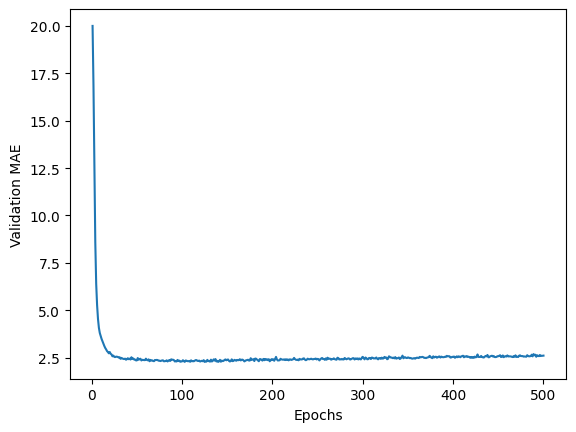

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

排除前10個資料點，繪製驗證分數

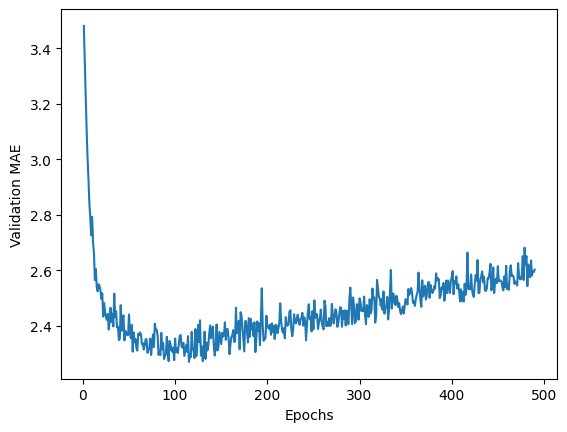

In [ ]:
truncated_mae_history = average_mae_history[10:]
plt.plot(range(1, len(truncated_mae_history) + 1), truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

訓練最終模型

In [ ]:
model = build_model() #建立一個用最佳參數編譯過的新模型
model.fit(train_data, train_targets, #以所有資料進行訓練
     epochs=130, batch_size=16, verbose=0)
test_mse_score, test_mae_score = model.evaluate(test_data, test_targets)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13.5323 - mae: 2.6302 


In [ ]:
test_mae_score

2.7545955181121826

# 在新資料上進行預測

In [ ]:
predictions = model.predict(test_data)
predictions[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([9.376246], dtype=float32)